In [4]:
# ============================================
# CUSTOMER CHURN ANALYSIS - STEP 1
# Load & Understand Dataset
# ============================================

import pandas as pd
import numpy as np

# 1. Load CSV file
df = pd.read_csv("C:\\Users\\hp\\Downloads\\customer_churn.csv")                                              

print("========== FIRST 5 ROWS ==========")
display(df.head())

# 3. Dataset shape
print("\n========== DATASET SHAPE ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# 4. Column names
print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

# 5. Dataset information
print("\n========== DATASET INFORMATION ==========")
df.info()

# 6. Statistical summary
print("\n========== STATISTICAL SUMMARY ==========")
display(df.describe(include="all").T)

# 7. Missing values
print("\n========== MISSING VALUES ==========")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# 8. Duplicate records
print("\n========== DUPLICATE RECORDS ==========")
print("Total duplicate rows:", df.duplicated().sum())

# 9. Unique values in each column
print("\n========== UNIQUE VALUES ==========")
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

# 10. Check Churn column
if "Churn" in df.columns:
    print("\n========== CHURN DISTRIBUTION ==========")
    print(df["Churn"].value_counts())
    
    print("\n========== CHURN PERCENTAGE ==========")
    print((df["Churn"].value_counts(normalize=True) * 100).round(2))
else:
    print("\n'Churn' column not found. Check the column name.")

========== FIRST 5 ROWS ==========


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,InternetService,PhoneService,PaymentMethod,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0,No,No,66,One year,Fiber optic,Yes,Electronic check,Yes,79.47,5185.07,No
1,CUST00002,Female,1,No,No,24,Month-to-month,Fiber optic,Yes,Credit card,No,77.57,1995.87,Yes
2,CUST00003,Male,0,No,No,60,Month-to-month,Fiber optic,Yes,Electronic check,Yes,77.08,4604.47,No
3,CUST00004,Male,0,Yes,No,25,Month-to-month,No,Yes,Credit card,No,35.73,955.24,No
4,CUST00005,Male,0,Yes,No,33,Month-to-month,Fiber optic,Yes,Mailed check,Yes,69.77,2262.30,No



========== DATASET SHAPE ==========
Rows: 7043
Columns: 14

========== COLUMN NAMES ==========
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'Contract', 'InternetService', 'PhoneService', 'PaymentMethod', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn']

========== DATASET INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   Contract          7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   PhoneService      7043 non-null   object 
 9   PaymentMethod     7043 non-n

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,CUST00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3550,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.153486,0.360481,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3636,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,36.319466,21.024165,0.0,18.0,37.0,54.0,72.0
Contract,7043,3,Month-to-month,3971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PhoneService,7043,2,Yes,6346,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,7043,4,Electronic check,2339,NaN,NaN,NaN,NaN,NaN,NaN,NaN



========== MISSING VALUES ==========
MonthlyCharges    15
TotalCharges      15
dtype: int64

========== DUPLICATE RECORDS ==========
Total duplicate rows: 0

========== UNIQUE VALUES ==========
customerID: 7043 unique values
gender: 2 unique values
SeniorCitizen: 2 unique values
Partner: 2 unique values
Dependents: 2 unique values
tenure: 73 unique values
Contract: 3 unique values
InternetService: 3 unique values
PhoneService: 2 unique values
PaymentMethod: 4 unique values
PaperlessBilling: 2 unique values
MonthlyCharges: 4471 unique values
TotalCharges: 6913 unique values
Churn: 2 unique values

========== CHURN DISTRIBUTION ==========
Churn
No     5593
Yes    1450
Name: count, dtype: int64

========== CHURN PERCENTAGE ==========
Churn
No     79.41
Yes    20.59
Name: proportion, dtype: float64


In [6]:
# ============================================
# CUSTOMER CHURN ANALYSIS - STEP 2
# DATA CLEANING & PREPROCESSING
# ============================================

import pandas as pd
import numpy as np

# 1. Load dataset
df = pd.read_csv("C:\\Users\\hp\\Downloads\\customer_churn.csv")

print("========== ORIGINAL DATASET ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


# 2. Check duplicate rows
print("\n========== DUPLICATES ==========")
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

# Remove duplicates
df = df.drop_duplicates()

print("Rows after removing duplicates:", df.shape[0])


# 3. Check missing values
print("\n========== MISSING VALUES BEFORE CLEANING ==========")
missing = df.isnull().sum()
print(missing[missing > 0])


# 4. Check data types
print("\n========== DATA TYPES BEFORE CLEANING ==========")
print(df.dtypes)


# 5. Convert TotalCharges and MonthlyCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")


# 6. Handle missing values
# TotalCharges → fill with median
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

# MonthlyCharges → fill with median
df["MonthlyCharges"] = df["MonthlyCharges"].fillna(
    df["MonthlyCharges"].median()
)


# 7. Check missing values after cleaning
print("\n========== MISSING VALUES AFTER CLEANING ==========")
missing_after = df.isnull().sum()

if missing_after.sum() == 0:
    print("No missing values remaining.")
else:
    print(missing_after[missing_after > 0])


# 8. Check for invalid values
print("\n========== INVALID VALUES CHECK ==========")

print("Negative MonthlyCharges:",
      (df["MonthlyCharges"] < 0).sum())

print("Negative TotalCharges:",
      (df["TotalCharges"] < 0).sum())

print("Negative Tenure:",
      (df["tenure"] < 0).sum())


# 9. Check categorical values
print("\n========== CATEGORICAL VALUES ==========")

categorical_columns = df.select_dtypes(
    include="object"
).columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


# 10. Final dataset information
print("\n========== FINAL DATASET INFO ==========")
df.info()


# 11. Final dataset shape
print("\n========== FINAL DATASET SHAPE ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


# 12. Display cleaned dataset
print("\n========== CLEANED DATASET ==========")
display(df.head())

========== ORIGINAL DATASET ==========
Rows: 7043
Columns: 14

========== DUPLICATES ==========
Duplicate rows: 0
Rows after removing duplicates: 7043

========== MISSING VALUES BEFORE CLEANING ==========
MonthlyCharges    15
TotalCharges      15
dtype: int64

========== DATA TYPES BEFORE CLEANING ==========
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
Contract             object
InternetService      object
PhoneService         object
PaymentMethod        object
PaperlessBilling     object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

========== MISSING VALUES AFTER CLEANING ==========
No missing values remaining.

========== INVALID VALUES CHECK ==========
Negative MonthlyCharges: 0
Negative TotalCharges: 0
Negative Tenure: 0

========== CATEGORICAL VALUES ==========

customerID:
['CUST00001' 'CUST00002' 'CUST00

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,InternetService,PhoneService,PaymentMethod,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0,No,No,66,One year,Fiber optic,Yes,Electronic check,Yes,79.47,5185.07,No
1,CUST00002,Female,1,No,No,24,Month-to-month,Fiber optic,Yes,Credit card,No,77.57,1995.87,Yes
2,CUST00003,Male,0,No,No,60,Month-to-month,Fiber optic,Yes,Electronic check,Yes,77.08,4604.47,No
3,CUST00004,Male,0,Yes,No,25,Month-to-month,No,Yes,Credit card,No,35.73,955.24,No
4,CUST00005,Male,0,Yes,No,33,Month-to-month,Fiber optic,Yes,Mailed check,Yes,69.77,2262.30,No


========== CUSTOMER OVERVIEW ==========
Total Customers: 7043

========== CHURN COUNT ==========
Churn
No     5593
Yes    1450
Name: count, dtype: int64

========== CHURN PERCENTAGE ==========
Churn
No     79.41
Yes    20.59
Name: proportion, dtype: float64

========== CHURN RATE ==========
Customer Churn Rate: 20.59%


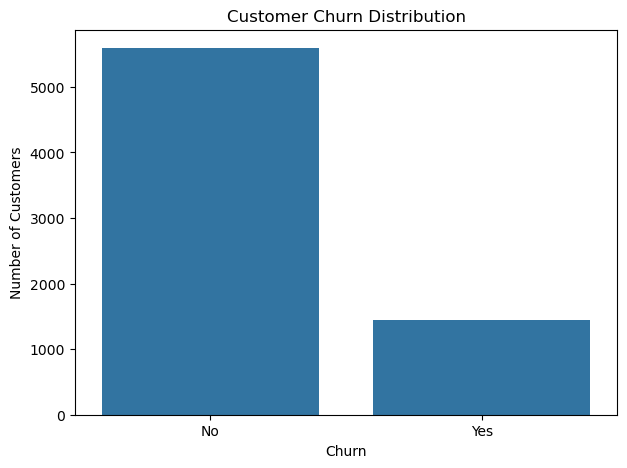

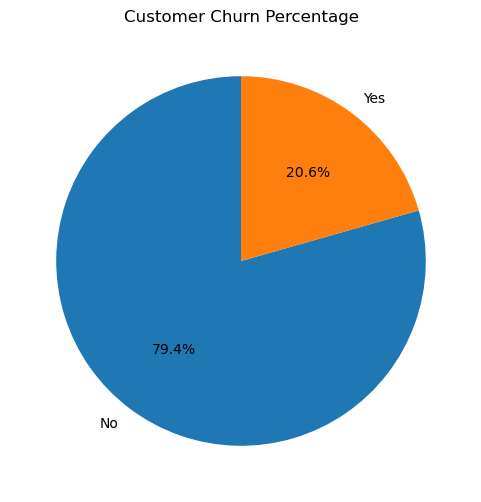


========== CONTRACT-WISE CHURN ==========


Churn,No,Yes
Contract,,
Month-to-month,75.02,24.98
One year,81.61,18.39
Two year,88.10,11.90


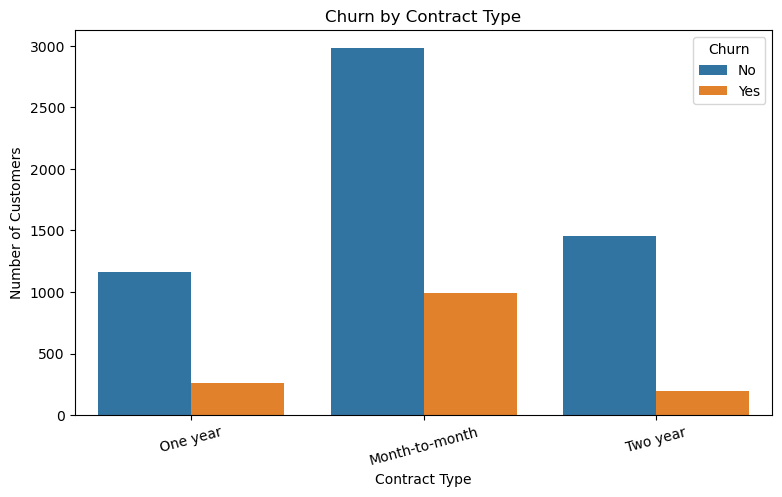

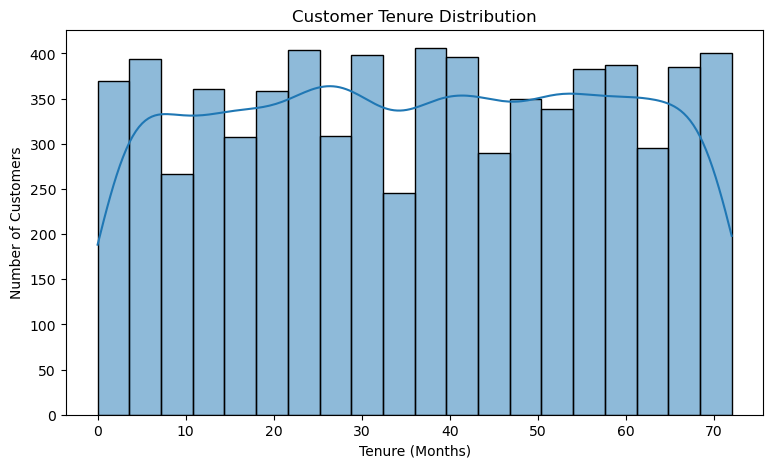

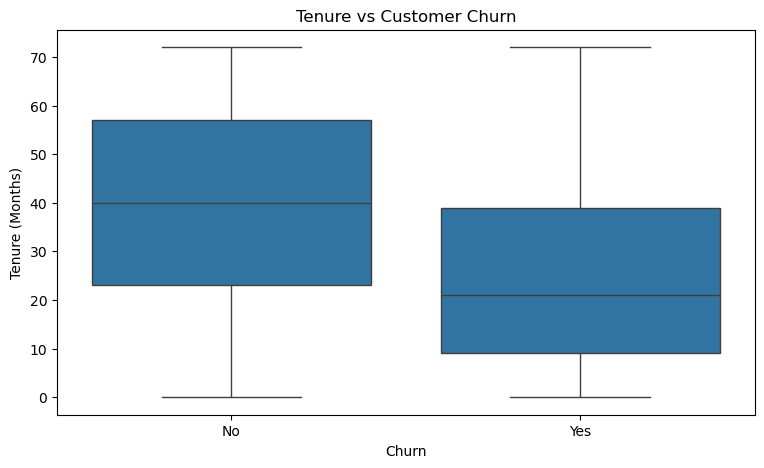

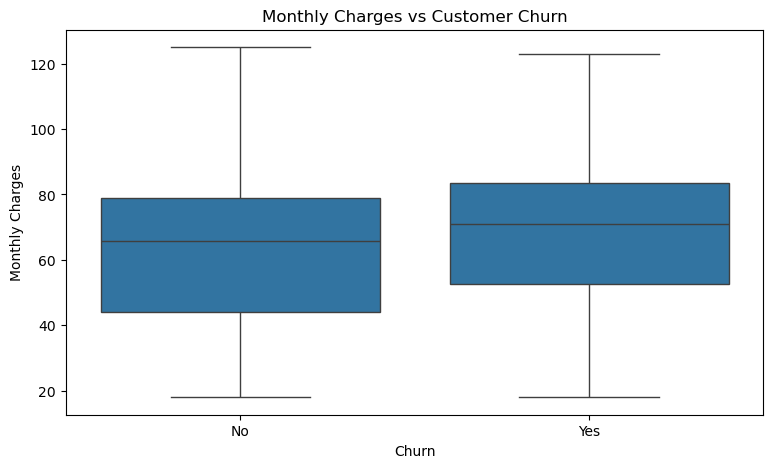


========== NUMERICAL INSIGHTS ==========
Average Monthly Charges: 62.52
Average Tenure: 36.32 months
Average Monthly Charges - Churned: 66.28
Average Monthly Charges - Non-Churned: 61.55
Average Tenure - Churned: 25.45
Average Tenure - Non-Churned: 39.14


In [7]:
# ============================================
# CUSTOMER CHURN ANALYSIS - STEP 3
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("C:\\Users\\hp\\Downloads\\customer_churn.csv")

# Convert columns to correct data types
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["MonthlyCharges"] = pd.to_numeric(df["MonthlyCharges"], errors="coerce")

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
df["MonthlyCharges"] = df["MonthlyCharges"].fillna(df["MonthlyCharges"].median())


# --------------------------------------------
# 1. TOTAL CUSTOMERS
# --------------------------------------------

total_customers = df.shape[0]

print("========== CUSTOMER OVERVIEW ==========")
print("Total Customers:", total_customers)


# --------------------------------------------
# 2. CHURNED VS NON-CHURNED CUSTOMERS
# --------------------------------------------

churn_count = df["Churn"].value_counts()

print("\n========== CHURN COUNT ==========")
print(churn_count)


# --------------------------------------------
# 3. CHURN PERCENTAGE
# --------------------------------------------

churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print("\n========== CHURN PERCENTAGE ==========")
print(churn_percentage.round(2))


# --------------------------------------------
# 4. CHURN RATE
# --------------------------------------------

churn_rate = (
    df["Churn"].value_counts(normalize=True)["Yes"] * 100
)

print("\n========== CHURN RATE ==========")
print(f"Customer Churn Rate: {churn_rate:.2f}%")


# --------------------------------------------
# 5. CHURN DISTRIBUTION - COUNT PLOT
# --------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()


# --------------------------------------------
# 6. CHURN DISTRIBUTION - PIE CHART
# --------------------------------------------

plt.figure(figsize=(6, 6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")
plt.ylabel("")

plt.show()


# --------------------------------------------
# 7. CONTRACT-WISE CHURN
# --------------------------------------------

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("\n========== CONTRACT-WISE CHURN ==========")
display(contract_churn.round(2))


# --------------------------------------------
# 8. CONTRACT-WISE CHURN VISUALIZATION
# --------------------------------------------

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.show()


# --------------------------------------------
# 9. TENURE DISTRIBUTION
# --------------------------------------------

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="tenure",
    bins=20,
    kde=True
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()


# --------------------------------------------
# 10. TENURE VS CHURN
# --------------------------------------------

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()


# --------------------------------------------
# 11. MONTHLY CHARGES VS CHURN
# --------------------------------------------

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()


# --------------------------------------------
# 12. BASIC NUMERICAL INSIGHTS
# --------------------------------------------

print("\n========== NUMERICAL INSIGHTS ==========")

print(
    "Average Monthly Charges:",
    round(df["MonthlyCharges"].mean(), 2)
)

print(
    "Average Tenure:",
    round(df["tenure"].mean(), 2),
    "months"
)

print(
    "Average Monthly Charges - Churned:",
    round(
        df.loc[df["Churn"] == "Yes", "MonthlyCharges"].mean(),
        2
    )
)

print(
    "Average Monthly Charges - Non-Churned:",
    round(
        df.loc[df["Churn"] == "No", "MonthlyCharges"].mean(),
        2
    )
)

print(
    "Average Tenure - Churned:",
    round(
        df.loc[df["Churn"] == "Yes", "tenure"].mean(),
        2
    )
)

print(
    "Average Tenure - Non-Churned:",
    round(
        df.loc[df["Churn"] == "No", "tenure"].mean(),
        2
    )
)

========== CHURN BY INTERNET SERVICE ==========


Churn,No,Yes
InternetService,,
DSL,82.43,17.57
Fiber optic,75.30,24.70
No,82.90,17.10


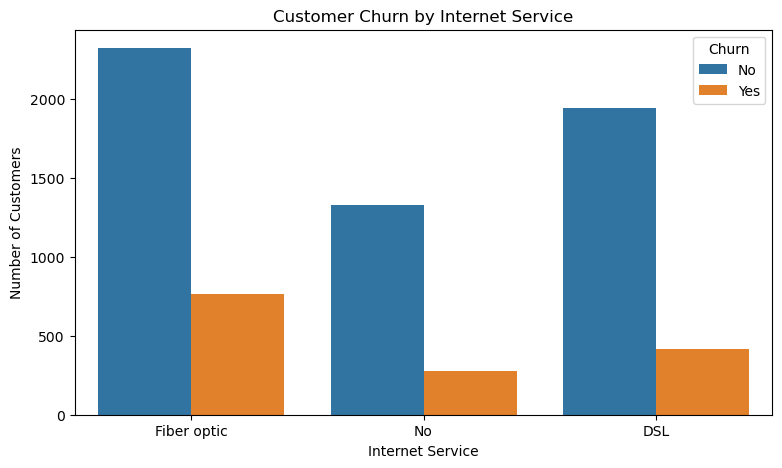


========== CHURN BY PAYMENT METHOD ==========


Churn,No,Yes
PaymentMethod,,
Bank transfer,81.49,18.51
Credit card,79.90,20.10
Electronic check,76.61,23.39
Mailed check,81.01,18.99


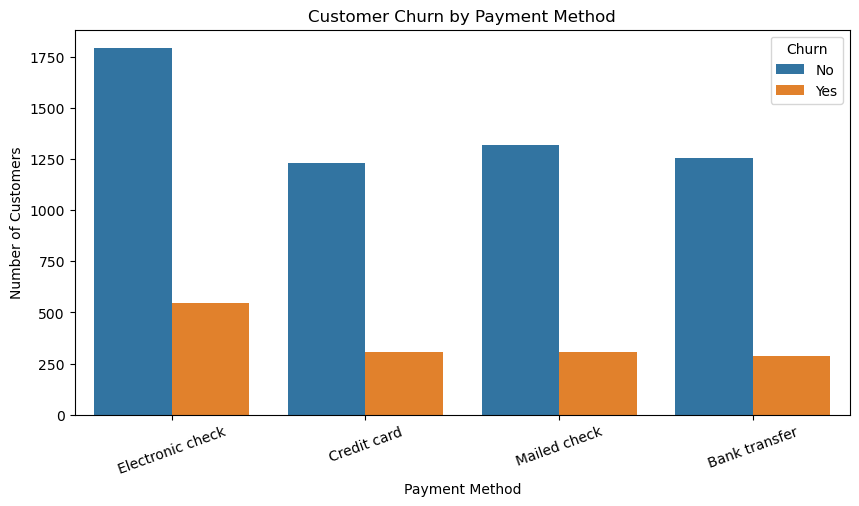


========== CHURN BY SENIOR CITIZEN ==========


Churn,No,Yes
SeniorCitizen,,
0,80.21,19.79
1,75.02,24.98


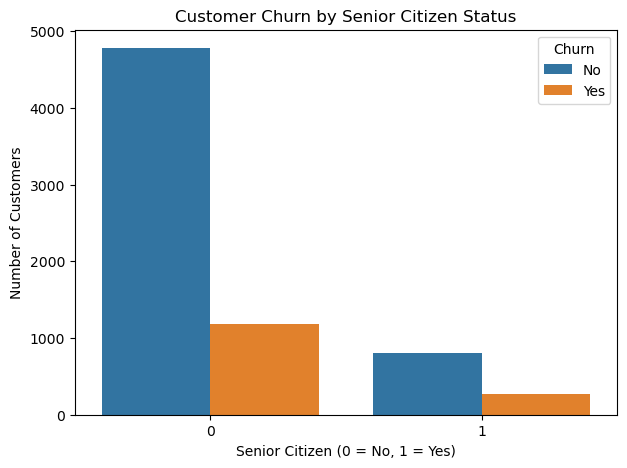


========== CHURN BY PAPERLESS BILLING ==========


Churn,No,Yes
PaperlessBilling,,
No,81.70,18.30
Yes,77.78,22.22


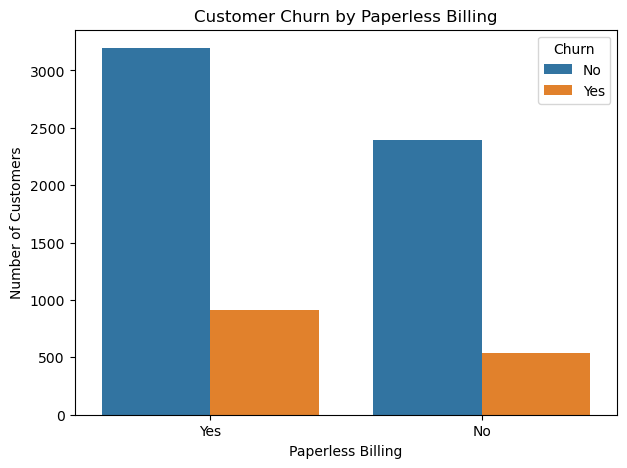


========== CHURN BY PARTNER ==========


Churn,No,Yes
Partner,,
No,77.31,22.69
Yes,81.66,18.34


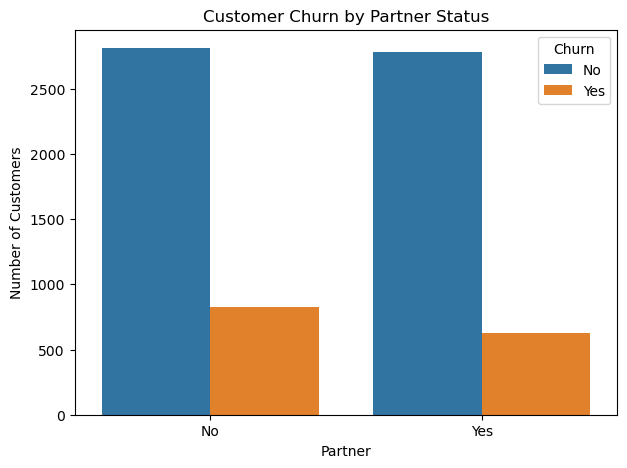


========== CHURN BY DEPENDENTS ==========


Churn,No,Yes
Dependents,,
No,78.27,21.73
Yes,82.03,17.97


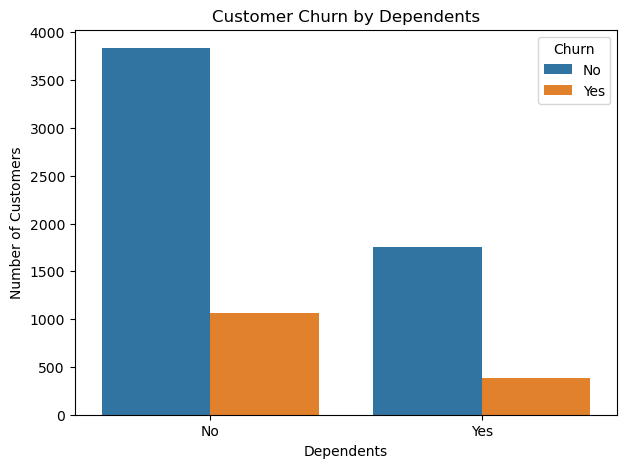


========== CHURN BY GENDER ==========


Churn,No,Yes
gender,,
Female,79.99,20.01
Male,78.85,21.15


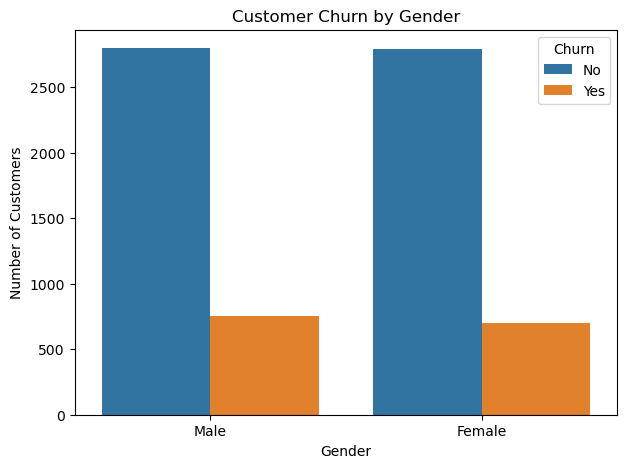


========== CHURN BY TENURE GROUP ==========


Churn,No,Yes
TenureGroup,,
0-6 Months,57.99,42.01
7-12 Months,64.88,35.12
13-24 Months,71.86,28.14
25-48 Months,81.33,18.67
49-72 Months,90.62,9.38


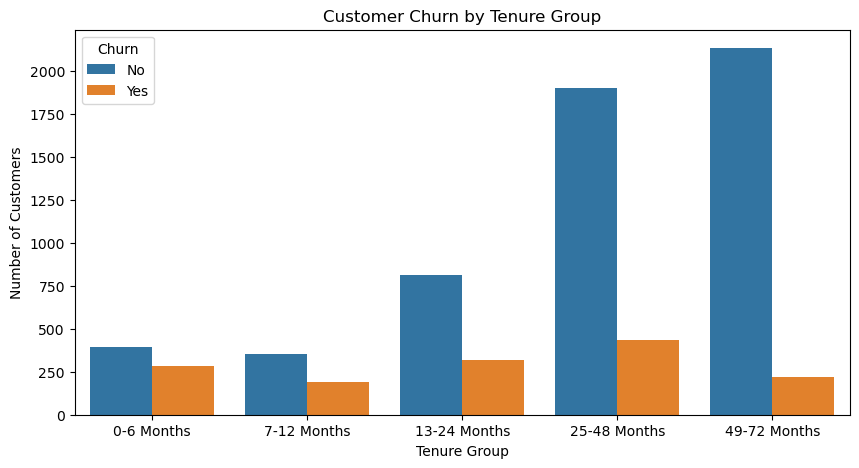


========== CHURN BY MONTHLY CHARGES ==========


Churn,No,Yes
MonthlyChargeGroup,,
Low (0-40),82.66,17.34
Medium (41-70),81.85,18.15
High (71-100),76.08,23.92
Very High (101+),73.50,26.50


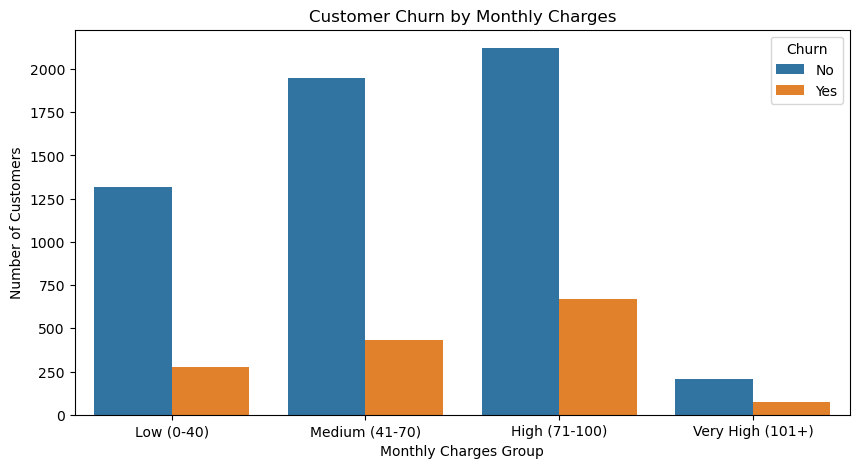


========== CUSTOMER BEHAVIOUR SUMMARY ==========
Highest churn by contract: Month-to-month
Highest churn by internet service: Fiber optic
Highest churn by payment method: Electronic check
Highest churn by tenure group: 0-6 Months
Highest churn by monthly charge group: Very High (101+)


In [8]:
# ============================================
# CUSTOMER CHURN ANALYSIS - STEP 4
# CUSTOMER BEHAVIOUR ANALYSIS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:\\Users\\hp\\Downloads\\customer_churn.csv")

# Convert numeric columns
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"], errors="coerce"
)

df["MonthlyCharges"] = pd.to_numeric(
    df["MonthlyCharges"], errors="coerce"
)

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

df["MonthlyCharges"] = df["MonthlyCharges"].fillna(
    df["MonthlyCharges"].median()
)


# --------------------------------------------
# 1. CHURN BY INTERNET SERVICE
# --------------------------------------------

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print("========== CHURN BY INTERNET SERVICE ==========")
display(internet_churn.round(2))


plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()


# --------------------------------------------
# 2. CHURN BY PAYMENT METHOD
# --------------------------------------------

payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print("\n========== CHURN BY PAYMENT METHOD ==========")
display(payment_churn.round(2))


plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()


# --------------------------------------------
# 3. CHURN BY SENIOR CITIZEN
# --------------------------------------------

senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print("\n========== CHURN BY SENIOR CITIZEN ==========")
display(senior_churn.round(2))


plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()


# --------------------------------------------
# 4. CHURN BY PAPERLESS BILLING
# --------------------------------------------

paperless_churn = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

print("\n========== CHURN BY PAPERLESS BILLING ==========")
display(paperless_churn.round(2))


plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="PaperlessBilling",
    hue="Churn"
)

plt.title("Customer Churn by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Number of Customers")

plt.show()


# --------------------------------------------
# 5. CHURN BY PARTNER
# --------------------------------------------

partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

print("\n========== CHURN BY PARTNER ==========")
display(partner_churn.round(2))


plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Partner",
    hue="Churn"
)

plt.title("Customer Churn by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.show()


# --------------------------------------------
# 6. CHURN BY DEPENDENTS
# --------------------------------------------

dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

print("\n========== CHURN BY DEPENDENTS ==========")
display(dependents_churn.round(2))


plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn"
)

plt.title("Customer Churn by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.show()


# --------------------------------------------
# 7. CHURN BY GENDER
# --------------------------------------------

gender_churn = pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

print("\n========== CHURN BY GENDER ==========")
display(gender_churn.round(2))


plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()


# --------------------------------------------
# 8. CREATE TENURE GROUPS
# --------------------------------------------

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ]
)

tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

print("\n========== CHURN BY TENURE GROUP ==========")
display(tenure_churn.round(2))


plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="TenureGroup",
    hue="Churn"
)

plt.title("Customer Churn by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Number of Customers")

plt.show()


# --------------------------------------------
# 9. CHURN BY MONTHLY CHARGES GROUP
# --------------------------------------------

df["MonthlyChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0, 40, 70, 100, 130],
    labels=[
        "Low (0-40)",
        "Medium (41-70)",
        "High (71-100)",
        "Very High (101+)"
    ]
)

charges_churn = pd.crosstab(
    df["MonthlyChargeGroup"],
    df["Churn"],
    normalize="index"
) * 100

print("\n========== CHURN BY MONTHLY CHARGES ==========")
display(charges_churn.round(2))


plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="MonthlyChargeGroup",
    hue="Churn"
)

plt.title("Customer Churn by Monthly Charges")
plt.xlabel("Monthly Charges Group")
plt.ylabel("Number of Customers")

plt.show()


# --------------------------------------------
# 10. SUMMARY OF CUSTOMER BEHAVIOUR
# --------------------------------------------

print("\n========== CUSTOMER BEHAVIOUR SUMMARY ==========")

print(
    "Highest churn by contract:",
    df.groupby("Contract", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
      .idxmax()
)

print(
    "Highest churn by internet service:",
    df.groupby("InternetService", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
      .idxmax()
)

print(
    "Highest churn by payment method:",
    df.groupby("PaymentMethod", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
      .idxmax()
)

print(
    "Highest churn by tenure group:",
    df.groupby("TenureGroup", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
      .idxmax()
)

print(
    "Highest churn by monthly charge group:",
    df.groupby("MonthlyChargeGroup", observed=True)["Churn"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
      .idxmax()
)

========== CORRELATION MATRIX ==========


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChurnNumeric
SeniorCitizen,1.000,-0.009,-0.010,-0.018,0.046
tenure,-0.009,1.000,0.009,0.790,-0.263
MonthlyCharges,-0.010,0.009,1.000,0.535,0.079
TotalCharges,-0.018,0.790,0.535,1.000,-0.172
ChurnNumeric,0.046,-0.263,0.079,-0.172,1.000



========== CORRELATION WITH CHURN ==========


MonthlyCharges    0.079
SeniorCitizen     0.046
TotalCharges     -0.172
tenure           -0.263
Name: ChurnNumeric, dtype: float64

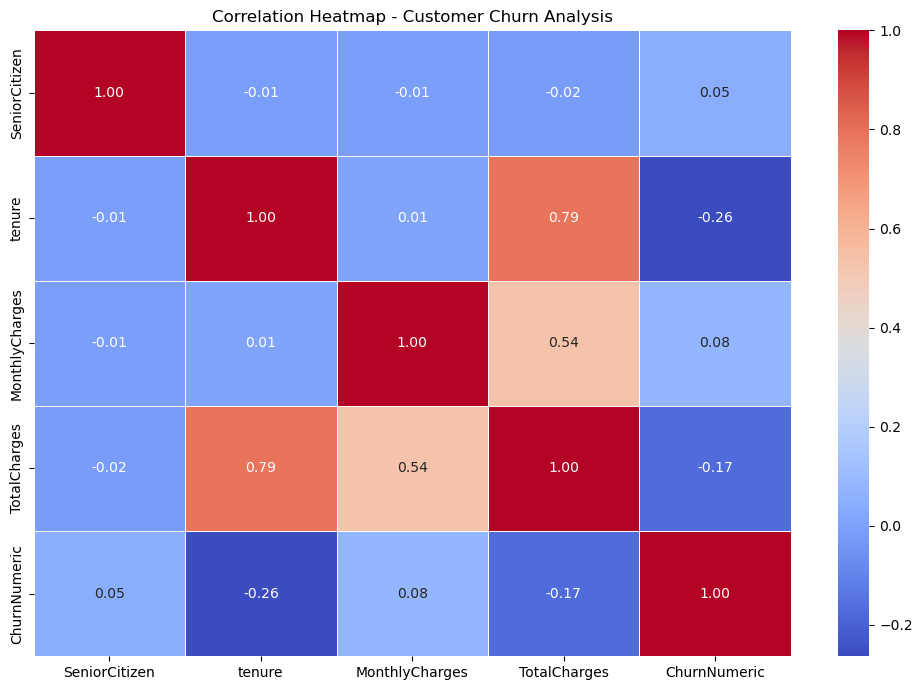


========== CHURN DRIVER RANKING ==========
1. tenure: -0.263
2. TotalCharges: -0.172
3. MonthlyCharges: 0.079
4. SeniorCitizen: 0.046


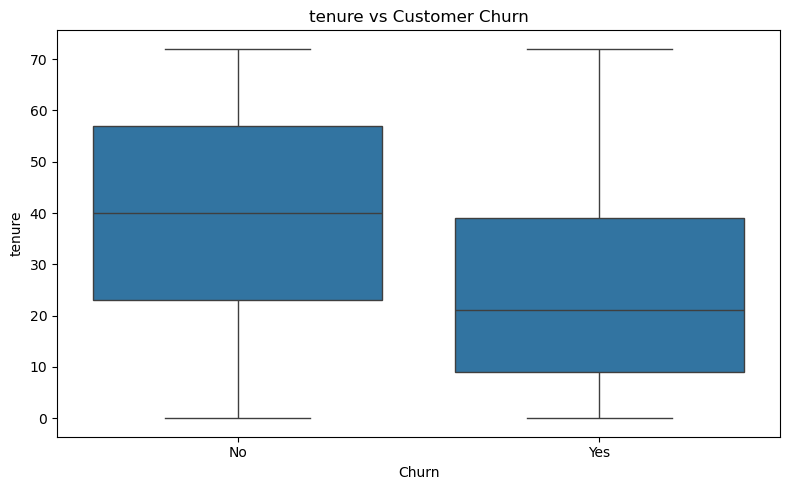

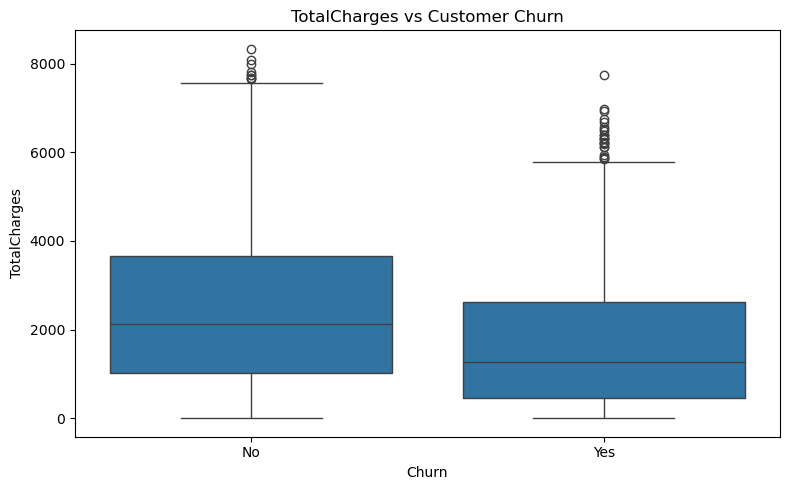

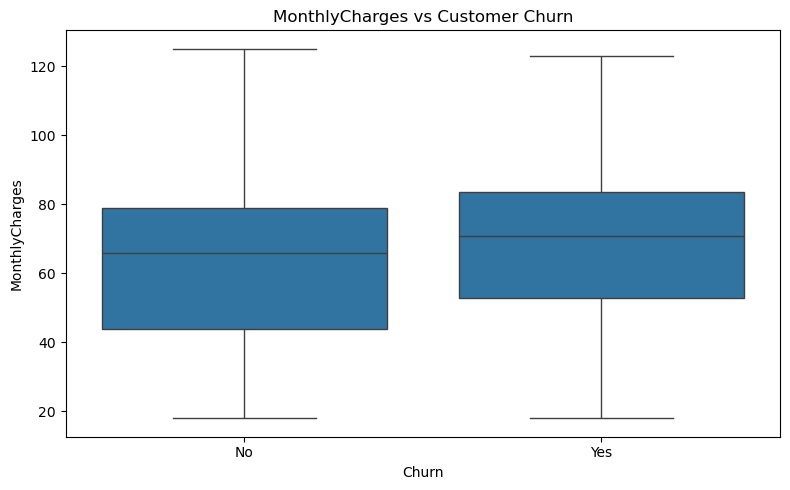

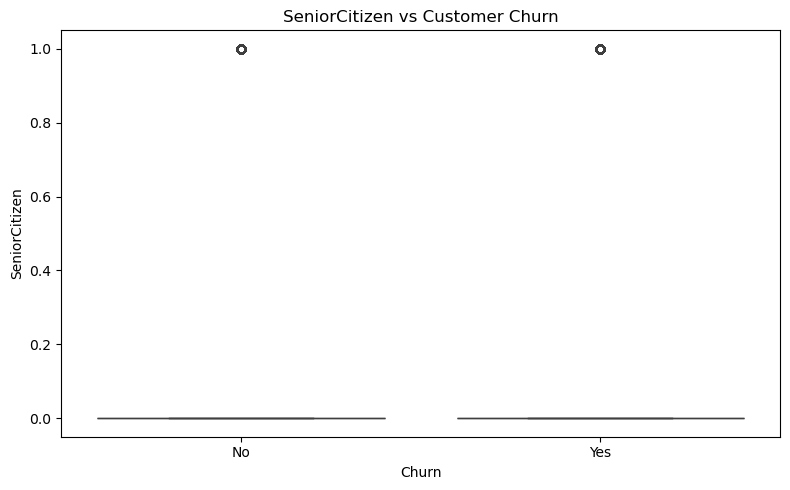


========== INTERPRETATION ==========
MonthlyCharges: positive correlation with churn (0.079)
SeniorCitizen: positive correlation with churn (0.046)
TotalCharges: negative correlation with churn (-0.172)
tenure: negative correlation with churn (-0.263)


In [9]:
# ============================================
# CUSTOMER CHURN ANALYSIS - STEP 5
# CORRELATION ANALYSIS & CHURN DRIVERS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("C:\\Users\\hp\\Downloads\\customer_churn.csv")

# Convert numeric columns
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"], errors="coerce"
)

df["MonthlyCharges"] = pd.to_numeric(
    df["MonthlyCharges"], errors="coerce"
)

# Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

df["MonthlyCharges"] = df["MonthlyCharges"].fillna(
    df["MonthlyCharges"].median()
)


# --------------------------------------------
# 1. CONVERT CHURN INTO NUMERIC
# --------------------------------------------

df["ChurnNumeric"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})


# --------------------------------------------
# 2. SELECT NUMERICAL COLUMNS
# --------------------------------------------

numeric_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ChurnNumeric"
]

correlation_data = df[numeric_columns]


# --------------------------------------------
# 3. CORRELATION MATRIX
# --------------------------------------------

correlation_matrix = correlation_data.corr()

print("========== CORRELATION MATRIX ==========")
display(correlation_matrix.round(3))


# --------------------------------------------
# 4. CORRELATION WITH CHURN
# --------------------------------------------

churn_correlation = (
    correlation_matrix["ChurnNumeric"]
    .drop("ChurnNumeric")
    .sort_values(ascending=False)
)

print("\n========== CORRELATION WITH CHURN ==========")
display(churn_correlation.round(3))


# --------------------------------------------
# 5. CORRELATION HEATMAP
# --------------------------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap - Customer Churn Analysis")
plt.tight_layout()
plt.show()


# --------------------------------------------
# 6. RANK CHURN-RELATED VARIABLES
# --------------------------------------------

ranked_drivers = (
    churn_correlation.abs()
    .sort_values(ascending=False)
)

print("\n========== CHURN DRIVER RANKING ==========")

for i, column in enumerate(ranked_drivers.index, start=1):
    correlation_value = churn_correlation[column]
    print(
        f"{i}. {column}: "
        f"{correlation_value:.3f}"
    )


# --------------------------------------------
# 7. VISUALIZE TOP CORRELATIONS
# --------------------------------------------

top_features = churn_correlation.abs().sort_values(
    ascending=False
).head(4).index

for feature in top_features:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Churn",
        y=feature
    )

    plt.title(f"{feature} vs Customer Churn")
    plt.xlabel("Churn")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()


# --------------------------------------------
# 8. INTERPRETATION
# --------------------------------------------

print("\n========== INTERPRETATION ==========")

for feature in churn_correlation.index:

    value = churn_correlation[feature]

    if value > 0:
        direction = "positive"
    else:
        direction = "negative"

    print(
        f"{feature}: {direction} correlation "
        f"with churn ({value:.3f})"
    )

========== TOP 5 CHURN-RELATED FEATURES ==========
1. tenure → Correlation: -0.263
2. TotalCharges → Correlation: -0.172
3. MonthToMonth → Correlation: 0.124
4. TwoYearContract → Correlation: -0.119
5. FiberOptic → Correlation: 0.090

========== TOP 5 TABLE ==========


,Feature,Correlation
0,tenure,-0.263
1,TotalCharges,-0.172
2,MonthToMonth,0.124
3,TwoYearContract,-0.119
4,FiberOptic,0.090


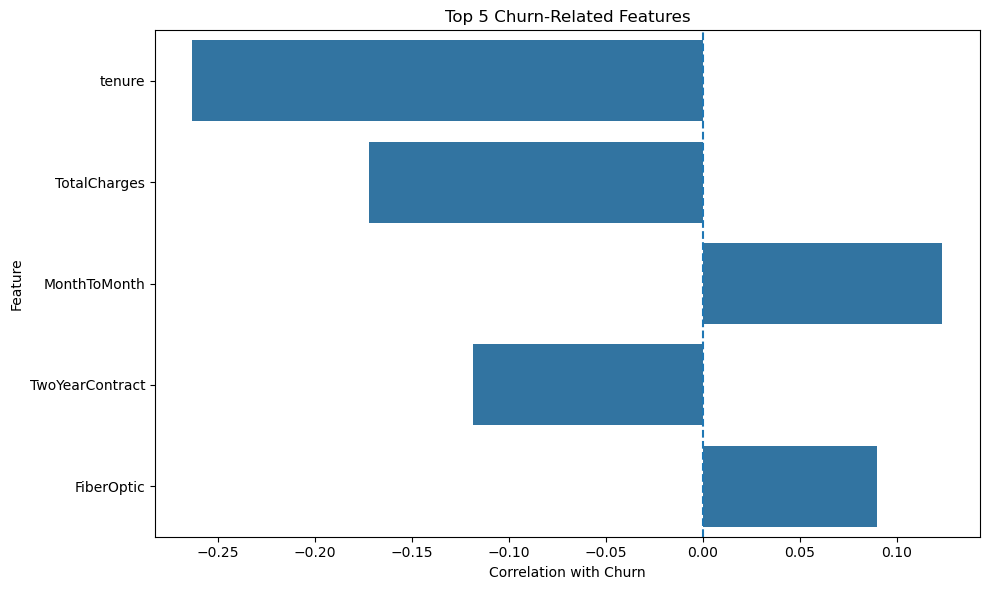


========== CONTRACT CHURN RATE ==========


Contract
Month-to-month    24.98
One year          18.39
Two year          11.90
Name: ChurnNumeric, dtype: float64


========== INTERNET SERVICE CHURN RATE ==========


InternetService
DSL            17.57
Fiber optic    24.70
No             17.10
Name: ChurnNumeric, dtype: float64


========== PAYMENT METHOD CHURN RATE ==========


PaymentMethod
Bank transfer       18.51
Credit card         20.10
Electronic check    23.39
Mailed check        18.99
Name: ChurnNumeric, dtype: float64

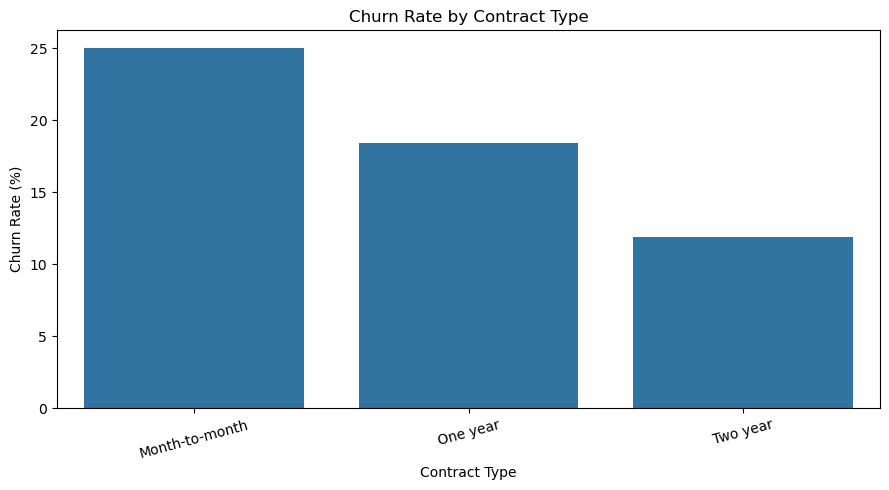

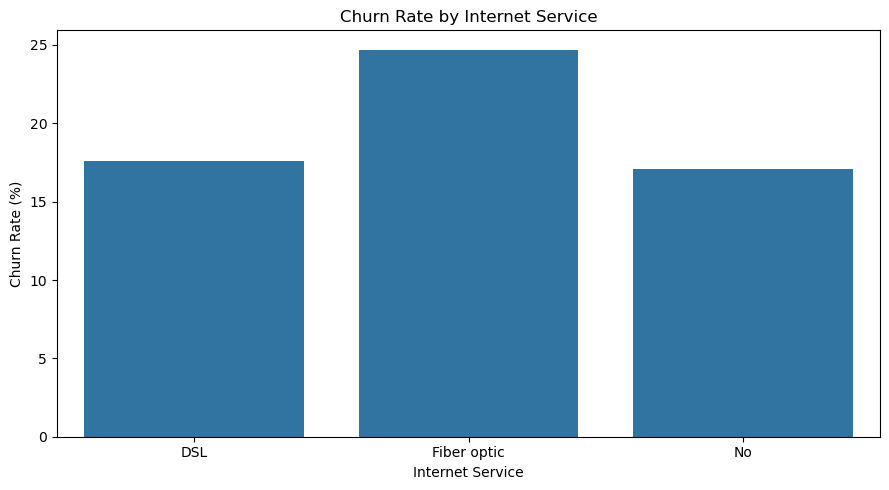

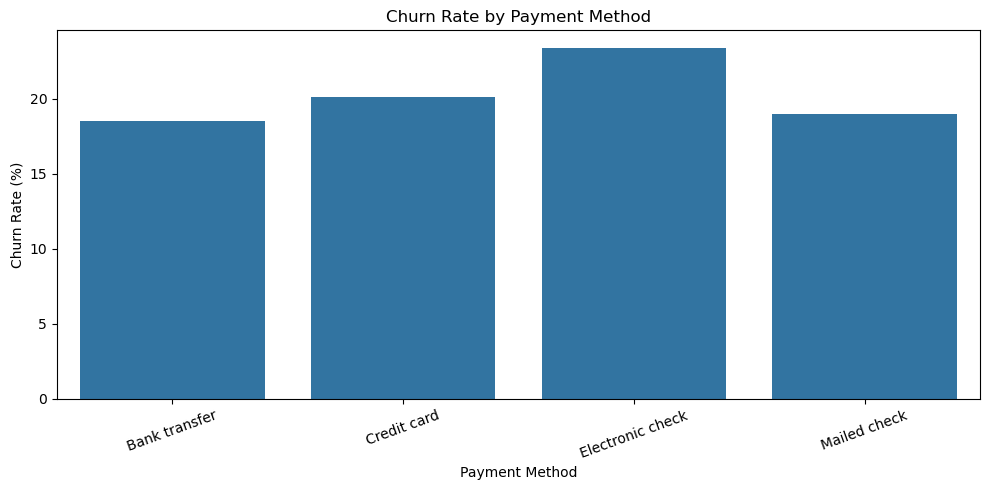

In [10]:
# ============================================
# CUSTOMER CHURN ANALYSIS - STEP 6
# CATEGORICAL ENCODING & TOP 5 CHURN DRIVERS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# 1. LOAD DATASET
# --------------------------------------------
df = pd.read_csv("C:\\Users\\hp\\Downloads\\customer_churn.csv")



# --------------------------------------------
# 2. DATA CLEANING
# --------------------------------------------

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["MonthlyCharges"] = pd.to_numeric(
    df["MonthlyCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

df["MonthlyCharges"] = df["MonthlyCharges"].fillna(
    df["MonthlyCharges"].median()
)


# --------------------------------------------
# 3. CHURN ENCODING
# --------------------------------------------

df["ChurnNumeric"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})


# --------------------------------------------
# 4. CREATE BINARY ENCODING
# --------------------------------------------

# Contract
df["MonthToMonth"] = (
    df["Contract"] == "Month-to-month"
).astype(int)

df["OneYearContract"] = (
    df["Contract"] == "One year"
).astype(int)

df["TwoYearContract"] = (
    df["Contract"] == "Two year"
).astype(int)


# Internet Service
df["FiberOptic"] = (
    df["InternetService"] == "Fiber optic"
).astype(int)

df["DSL"] = (
    df["InternetService"] == "DSL"
).astype(int)


# Payment Method
df["ElectronicCheck"] = (
    df["PaymentMethod"] == "Electronic check"
).astype(int)


# Paperless Billing
df["PaperlessBillingNumeric"] = (
    df["PaperlessBilling"] == "Yes"
).astype(int)


# Partner
df["PartnerNumeric"] = (
    df["Partner"] == "Yes"
).astype(int)


# Dependents
df["DependentsNumeric"] = (
    df["Dependents"] == "Yes"
).astype(int)


# Phone Service
df["PhoneServiceNumeric"] = (
    df["PhoneService"] == "Yes"
).astype(int)


# --------------------------------------------
# 5. SELECT FEATURES
# --------------------------------------------

features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "MonthToMonth",
    "OneYearContract",
    "TwoYearContract",
    "FiberOptic",
    "DSL",
    "ElectronicCheck",
    "PaperlessBillingNumeric",
    "PartnerNumeric",
    "DependentsNumeric",
    "PhoneServiceNumeric"
]


# --------------------------------------------
# 6. CORRELATION WITH CHURN
# --------------------------------------------

correlations = df[
    features + ["ChurnNumeric"]
].corr()["ChurnNumeric"].drop("ChurnNumeric")


# Sort by absolute correlation
top_5 = correlations.abs().sort_values(
    ascending=False
).head(5)


print("========== TOP 5 CHURN-RELATED FEATURES ==========")

for i, feature in enumerate(top_5.index, 1):

    print(
        f"{i}. {feature} "
        f"→ Correlation: "
        f"{correlations[feature]:.3f}"
    )


# --------------------------------------------
# 7. CREATE TOP 5 DATAFRAME
# --------------------------------------------

top_5_df = pd.DataFrame({
    "Feature": top_5.index,
    "Correlation": [
        correlations[x] for x in top_5.index
    ]
})

print("\n========== TOP 5 TABLE ==========")
display(top_5_df.round(3))


# --------------------------------------------
# 8. VISUALIZE TOP 5
# --------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_5_df,
    x="Correlation",
    y="Feature"
)

plt.title("Top 5 Churn-Related Features")
plt.xlabel("Correlation with Churn")
plt.ylabel("Feature")

plt.axvline(
    x=0,
    linestyle="--"
)

plt.tight_layout()
plt.show()


# --------------------------------------------
# 9. CHURN RATE BY IMPORTANT CATEGORIES
# --------------------------------------------

print("\n========== CONTRACT CHURN RATE ==========")

contract_rate = (
    df.groupby("Contract")["ChurnNumeric"]
    .mean() * 100
)

display(contract_rate.round(2))


print("\n========== INTERNET SERVICE CHURN RATE ==========")

internet_rate = (
    df.groupby("InternetService")["ChurnNumeric"]
    .mean() * 100
)

display(internet_rate.round(2))


print("\n========== PAYMENT METHOD CHURN RATE ==========")

payment_rate = (
    df.groupby("PaymentMethod")["ChurnNumeric"]
    .mean() * 100
)

display(payment_rate.round(2))


# --------------------------------------------
# 10. CONTRACT CHURN RATE GRAPH
# --------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    x=contract_rate.index,
    y=contract_rate.values
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


# --------------------------------------------
# 11. INTERNET SERVICE CHURN RATE GRAPH
# --------------------------------------------

plt.figure(figsize=(9, 5))

sns.barplot(
    x=internet_rate.index,
    y=internet_rate.values
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()


# --------------------------------------------
# 12. PAYMENT METHOD CHURN RATE GRAPH
# --------------------------------------------

plt.figure(figsize=(10, 5))

sns.barplot(
    x=payment_rate.index,
    y=payment_rate.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [11]:
# ============================================
# CUSTOMER CHURN ANALYSIS - STEP 7
# SQL ANALYSIS USING SQLITE
# ============================================

import sqlite3
import pandas as pd

# 1. Load CSV
df = pd.read_csv("C:\\Users\\hp\\Downloads\\customer_churn.csv")

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"], errors="coerce"
)

df["MonthlyCharges"] = pd.to_numeric(
    df["MonthlyCharges"], errors="coerce"
)

# 3. Fill missing values
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

df["MonthlyCharges"] = df["MonthlyCharges"].fillna(
    df["MonthlyCharges"].median()
)

# 4. Create SQLite database
conn = sqlite3.connect("customer_churn.db")

# 5. Upload DataFrame into SQL table
df.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

print("Dataset successfully loaded into SQLite!")

Dataset successfully loaded into SQLite!


In [12]:
# Total Customers

query = """
SELECT COUNT(*) AS total_customers
FROM customers;
"""

result = pd.read_sql_query(query, conn)

display(result)

,total_customers
0,7043


In [13]:
query = """
SELECT
    Contract,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3971,992,24.98
1,One year,1425,262,18.39
2,Two year,1647,196,11.90


In [14]:
query = """
SELECT
    CASE
        WHEN tenure <= 6 THEN '0-6 Months'
        WHEN tenure <= 12 THEN '7-12 Months'
        WHEN tenure <= 24 THEN '13-24 Months'
        WHEN tenure <= 48 THEN '25-48 Months'
        ELSE '49-72 Months'
    END AS tenure_group,

    COUNT(*) AS total_customers,

    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        AS churned_customers,

    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate

FROM customers

GROUP BY tenure_group

ORDER BY churn_rate DESC;
"""

result = pd.read_sql_query(query, conn)

display(result)

,tenure_group,total_customers,churned_customers,churn_rate
0,0-6 Months,676,284,42.01
1,7-12 Months,541,190,35.12
2,13-24 Months,1130,318,28.14
3,25-48 Months,2341,437,18.67
4,49-72 Months,2355,221,9.38


========== CUSTOMER CHURN INSIGHTS ==========

1. Overall Churn:
Churn
No     79.41
Yes    20.59
Name: proportion, dtype: float64

2. Contract-wise Churn (%):


Churn,No,Yes
Contract,,
Month-to-month,75.02,24.98
One year,81.61,18.39
Two year,88.10,11.90


3. Internet Service-wise Churn (%):


Churn,No,Yes
InternetService,,
DSL,82.43,17.57
Fiber optic,75.30,24.70
No,82.90,17.10


4. Payment Method-wise Churn (%):


Churn,No,Yes
PaymentMethod,,
Bank transfer,81.49,18.51
Credit card,79.90,20.10
Electronic check,76.61,23.39
Mailed check,81.01,18.99


5. Senior Citizen Churn (%):


Churn,No,Yes
SeniorCitizen,,
0,80.21,19.79
1,75.02,24.98


6. Paperless Billing Churn (%):


Churn,No,Yes
PaperlessBilling,,
No,81.70,18.30
Yes,77.78,22.22


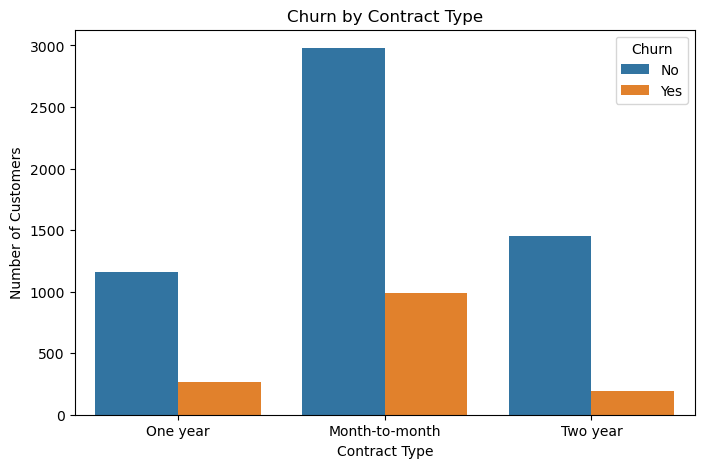

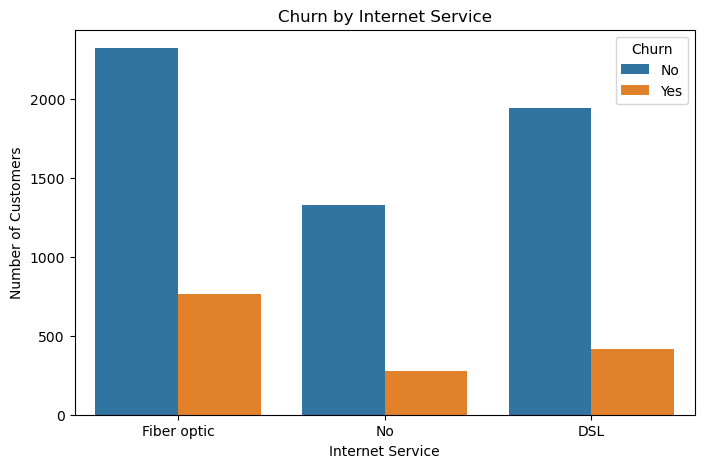

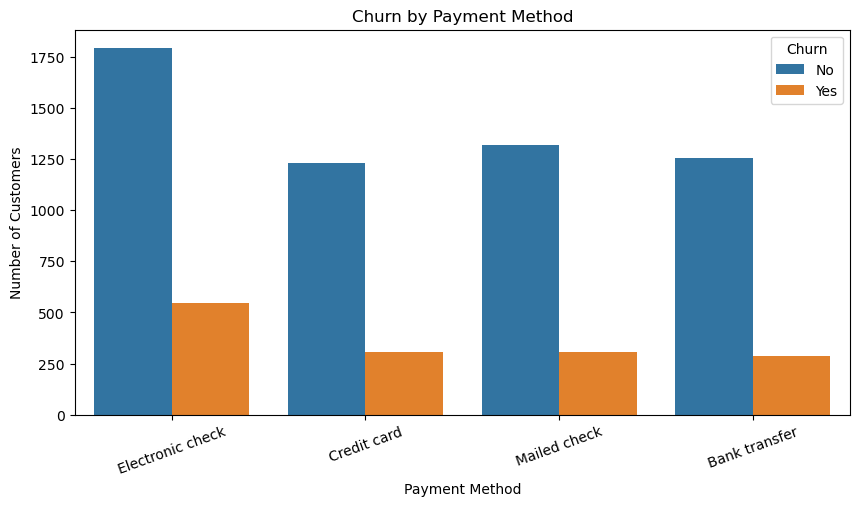

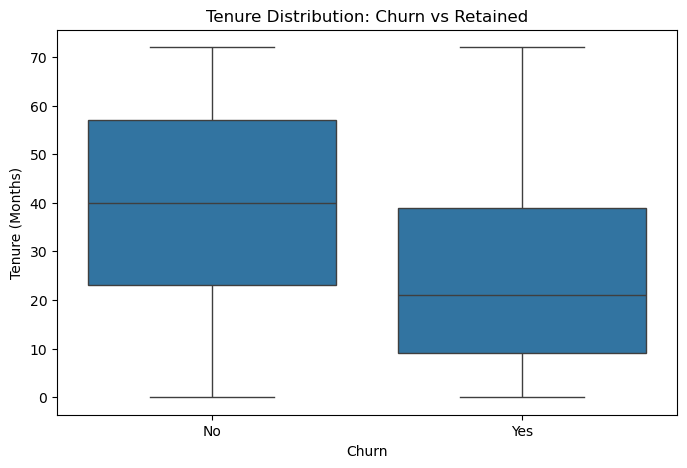

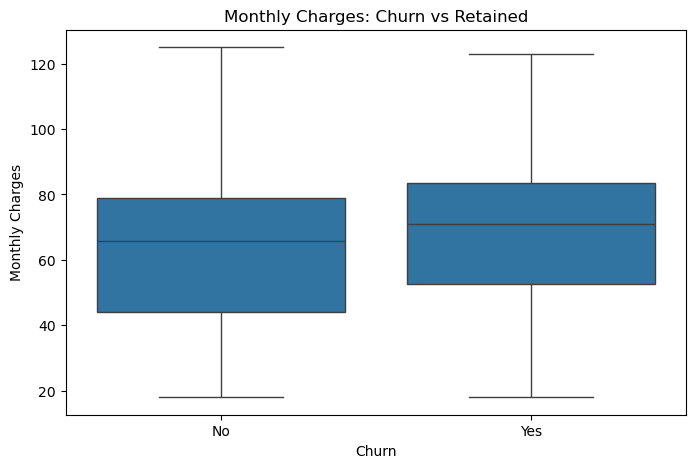


========== ANALYSIS COMPLETE ==========


In [15]:
# STEP 8 - BUSINESS INSIGHTS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Churn percentage by different factors
print("========== CUSTOMER CHURN INSIGHTS ==========\n")

# 1. Overall Churn
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print("1. Overall Churn:")
print(churn_rate.round(2))
print()

# 2. Contract-wise Churn
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("2. Contract-wise Churn (%):")
display(contract_churn.round(2))

# 3. Internet Service-wise Churn
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print("3. Internet Service-wise Churn (%):")
display(internet_churn.round(2))

# 4. Payment Method-wise Churn
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print("4. Payment Method-wise Churn (%):")
display(payment_churn.round(2))

# 5. Senior Citizen Churn
senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print("5. Senior Citizen Churn (%):")
display(senior_churn.round(2))

# 6. Paperless Billing Churn
paperless_churn = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
) * 100

print("6. Paperless Billing Churn (%):")
display(paperless_churn.round(2))


# ================= VISUALIZATIONS =================

# Contract
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()


# Internet Service
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()


# Payment Method
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()


# Tenure
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure Distribution: Churn vs Retained")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()


# Monthly Charges
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges: Churn vs Retained")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()


print("\n========== ANALYSIS COMPLETE ==========")

In [16]:
# STEP 9 - DASHBOARD DATA

# Basic KPIs
total_customers = len(df)
churned_customers = (df["Churn"] == "Yes").sum()
retained_customers = (df["Churn"] == "No").sum()
churn_rate = (churned_customers / total_customers) * 100
avg_monthly_charges = df["MonthlyCharges"].mean()

print("========== DASHBOARD KPIs ==========")
print(f"Total Customers       : {total_customers}")
print(f"Churned Customers     : {churned_customers}")
print(f"Retained Customers    : {retained_customers}")
print(f"Churn Rate            : {churn_rate:.2f}%")
print(f"Avg Monthly Charges   : {avg_monthly_charges:.2f}")


# Contract-wise churn rate
contract_dashboard = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

print("\nContract-wise Churn Rate:")
display(contract_dashboard.round(2))


# Internet Service-wise churn
internet_dashboard = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

print("\nInternet Service-wise Churn Rate:")
display(internet_dashboard.round(2))


# Payment Method-wise churn
payment_dashboard = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="ChurnRate")
)

print("\nPayment Method-wise Churn Rate:")
display(payment_dashboard.round(2))


print("\n========== DASHBOARD DATA READY ==========")

========== DASHBOARD KPIs ==========
Total Customers       : 7043
Churned Customers     : 1450
Retained Customers    : 5593
Churn Rate            : 20.59%
Avg Monthly Charges   : 62.52

Contract-wise Churn Rate:


,Contract,ChurnRate
0,Month-to-month,24.98
1,One year,18.39
2,Two year,11.90



Internet Service-wise Churn Rate:


,InternetService,ChurnRate
0,DSL,17.57
1,Fiber optic,24.70
2,No,17.10



Payment Method-wise Churn Rate:


,PaymentMethod,ChurnRate
0,Bank transfer,18.51
1,Credit card,20.10
2,Electronic check,23.39
3,Mailed check,18.99



========== DASHBOARD DATA READY ==========


In [18]:
# Export cleaned dataset for Tableau

df.to_csv("customer_churn_cleaned.csv", index=False)

print("Cleaned dataset exported successfully!")
print("File: customer_churn_cleaned.csv")

Cleaned dataset exported successfully!
File: customer_churn_cleaned.csv
